# Twitter Sentiment Analysis: From TF-IDF to Transformers
**Sai Rishitha Chittaluru · CSCE 676 Data Mining · Texas A&M University**

---

## Motivation

Social media platforms like Twitter generate hundreds of millions of messages every day, many of which express strong opinions about products, events, and public figures. Automatically identifying the sentiment behind these short, informal messages has significant real-world value — from brand monitoring and customer feedback analysis to public health tracking and financial forecasting.

However, tweet sentiment analysis is non-trivial. Tweets are short, noisy, and filled with slang, abbreviations, and informal language that traditional text mining methods struggle with. This project investigates how well different text representation methods — from classical TF-IDF features to modern transformer-based embeddings — can classify tweet sentiment, and where each approach succeeds or fails.

---

## Dataset & Paper

This project uses the **Sentiment140** dataset introduced by Go, Bhayani, and Huang (2009) in their Stanford CS224N paper *"Twitter Sentiment Classification using Distant Supervision."* The dataset contains 1.6 million tweets automatically labeled using emoticons — positive emoticons (e.g. `:)`) mark positive tweets and negative emoticons (e.g. `:(`) mark negative ones. This approach, called *distant supervision*, allowed large-scale labeling without manual annotation.

> **Dataset source:** Sentiment140 on Kaggle — https://www.kaggle.com/datasets/kazanova/sentiment140

---

## Research Questions

**RQ1:** How well can traditional TF-IDF based models classify tweet sentiment, and how do different text representations (unigrams vs. bigrams) affect performance?
*(Course technique · Text classification · Logistic Regression, Naive Bayes)*

**RQ2:** How does text complexity — specifically tweet length and vocabulary diversity — affect sentiment classification performance?
*(Course technique · Feature analysis · Logistic Regression)*

**RQ3:** Do transformer-based embeddings (DistilBERT) improve sentiment classification compared to TF-IDF baselines, and where do they fail?
*(Beyond-course technique · Contextual embeddings · DistilBERT fine-tuning)*

---

## Project Overview

This notebook tells the complete story of the project in five parts:

- **Part 1 — Data Loading & Preprocessing:** Load the raw 1.6M dataset, clean text, and produce a stratified 200K sample for modeling.
- **Part 2 — Exploratory Data Analysis:** Understand the dataset structure, class balance, tweet length, vocabulary, and TF-IDF sparsity.
- **Part 3 — RQ1:** TF-IDF baseline classification with Logistic Regression and Naive Bayes.
- **Part 4 — RQ2:** Performance analysis across tweet length and vocabulary diversity subgroups.
- **Part 5 — RQ3:** DistilBERT fine-tuning, evaluation, and error analysis vs. TF-IDF baseline.

---
# Part 1: Data Loading & Preprocessing

Before we can build any models, we need to get the raw data into a clean and usable format. This part covers four steps:

1. **Downloading the dataset** from Kaggle using the Kaggle API
2. **Loading the raw 1.6M tweets** and understanding the structure
3. **Cleaning the text** — removing URLs, @mentions, special characters, and normalizing the text
4. **Sampling 200K tweets** using stratified sampling to maintain class balance

The cleaning steps here are directly inspired by the preprocessing described in Go et al. (2009), where they replaced usernames, URLs, and repeated letters to reduce noise in the feature space. We extend this with additional normalization steps suited for modern text classification.

> **Note:** This notebook builds on the exploratory work done in Checkpoints 1 and 2. The full cleaning and sampling pipeline is re-run here from scratch for reproducibility and to tell a complete, connected story.

In [ ]:
# Mount Google Drive to save cleaned dataset
# so we don't have to re-run everything if the session restarts
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install the Kaggle library to download the dataset directly
!pip install kaggle -q

In [ ]:
# Upload kaggle.json API key
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the Sentiment140 dataset
!kaggle datasets download -d kazanova/sentiment140 -q
!unzip -q sentiment140.zip
!ls

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/kazanova/sentiment140
License(s): other
drive	     sample_data       training.1600000.processed.noemoticon.csv
kaggle.json  sentiment140.zip


## Loading the Raw Dataset

The raw dataset has no column headers, so we manually assign them based on the dataset documentation.
The columns are: `sentiment`, `tweet_id`, `date`, `query`, `user`, and `text`.

The sentiment column uses `0` for negative and `4` for positive — we convert this to a binary `label`
column (0 = negative, 1 = positive) for easier use in our models.

In [ ]:
import pandas as pd

# Load the raw dataset
# The file uses latin-1 encoding and has no header row
df_raw = pd.read_csv(
    "training.1600000.processed.noemoticon.csv",
    encoding="latin-1",
    header=None,
    names=["sentiment", "tweet_id", "date", "query", "user", "text"]
)

# Convert sentiment labels: 0 = negative, 4 = positive -> binary label
df_raw["label"] = (df_raw["sentiment"] == 4).astype(int)

print(f"Raw dataset shape: {df_raw.shape}")
print(f"\nLabel distribution:\n{df_raw['label'].value_counts()}")
df_raw.head()

Raw dataset shape: (1600000, 7)

Label distribution:
label
0    800000
1    800000
Name: count, dtype: int64


,sentiment,tweet_id,date,query,user,text,label
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...,0
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...,0
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire,0
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all....",0


## Text Cleaning

Raw tweets are noisy — they contain URLs, @mentions, hashtag symbols, and repeated characters
that don't carry sentiment information and add noise to our feature space.

We apply the following cleaning steps, inspired by Go et al. (2009):

- **Lowercase** all text for consistency
- **Remove URLs** (http/https links and www links)
- **Remove @mentions** (usernames don't carry sentiment)
- **Remove hashtag symbol** but keep the word (the word itself may carry meaning)
- **Remove repeated characters** — e.g. "sooooo" → "soo" (cap at 2 repetitions)
- **Strip extra whitespace**

We also remove duplicate tweets at this stage, as the same tweet appearing
multiple times could bias the model.

In [ ]:
import re

def clean_tweet(text):
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)
    # Remove @mentions
    text = re.sub(r"@\w+", "", text)
    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)
    # Collapse repeated characters to max 2 (e.g. "sooooo" -> "soo")
    text = re.sub(r"(.)\1{2,}", r"\1\1", text)
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    return text

# Apply cleaning
df_raw["text_clean"] = df_raw["text"].apply(clean_tweet)

# Remove duplicate tweets
before = len(df_raw)
df_raw = df_raw.drop_duplicates(subset="text_clean").reset_index(drop=True)
after = len(df_raw)

print(f"Removed {before - after:,} duplicate tweets")
print(f"Dataset size after deduplication: {after:,}")
df_raw[["text", "text_clean", "label"]].head()

Removed 61,096 duplicate tweets
Dataset size after deduplication: 1,538,904


,text,text_clean,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",- a that's a bummer. you shoulda got david car...,0
1,is upset that he can't update his Facebook by ...,is upset that he can't update his facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball. managed to sa...,0
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....","no, it's not behaving at all. i'm mad. why am ...",0


## Stratified Sampling

The full 1.6M dataset is computationally expensive for some of our models,
especially the exploratory analysis and transformer fine-tuning steps.

We take a **stratified random sample of 200K tweets** — meaning we sample
equally from positive and negative classes (100K each) to maintain the
natural 50/50 balance of the dataset.

A separate **stratified 50K subsample** of this 200K will be used later
for fine-tuning DistilBERT in RQ3, which is computationally expensive
even on a GPU. Using a subset for transformer fine-tuning is standard
practice in the literature — the TweetEval benchmark (Barbieri et al., 2020)
follows the same approach.

In [ ]:
from sklearn.model_selection import train_test_split

# Stratified sample of 200K tweets (100K positive, 100K negative)
df_200k, _ = train_test_split(
    df_raw,
    train_size=200000,
    stratify=df_raw["label"],
    random_state=42
)

df_200k = df_200k.reset_index(drop=True)

print(f"200K sample shape: {df_200k.shape}")
print(f"\nLabel distribution:\n{df_200k['label'].value_counts()}")

200K sample shape: (200000, 8)

Label distribution:
label
0    100729
1     99271
Name: count, dtype: int64


In [ ]:
import os

# Save the cleaned 200K sample to Google Drive
save_path = "/content/drive/MyDrive/CSCE676_Project/"
os.makedirs(save_path, exist_ok=True)

df_200k.to_csv(save_path + "cleaned_200k.csv", index=False)
print(f"Saved cleaned_200k.csv to Google Drive")
print(f"Shape: {df_200k.shape}")

Saved cleaned_200k.csv to Google Drive
Shape: (200000, 8)


## Part 1 Summary

In this part, I:

- Loaded the raw **1.6M tweet** Sentiment140 dataset with proper column names and binary labels
- Applied **text cleaning** — lowercasing, removing URLs, @mentions, hashtag symbols,
  collapsing repeated characters, and stripping whitespace
- Removed 61k **duplicate tweets** to avoid training bias
- Created a **stratified 200K sample** with balanced positive (100729) and negative classes (99271)
- Saved the cleaned dataset to Google Drive for use in subsequent parts

The cleaned dataset is now ready for exploratory analysis and model training.
In Part 2, we will take a closer look at the data before building any models.

---
# Part 2: Exploratory Data Analysis

Before building any models, it is important to understand the data we are working with.
In this part, we explore the cleaned 200K dataset to answer questions like:

- Are the sentiment classes balanced?
- How long are tweets on average?
- What are the most common words?
- How sparse is the TF-IDF representation?

These observations directly motivate our three research questions and the modeling
choices we make in the later parts.

In [ ]:
import pandas as pd

# Load the cleaned 200K sample saved in Part 1
df = pd.read_csv("/content/drive/MyDrive/CSCE676_Project/cleaned_200k.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset shape: (200000, 8)

Columns: ['sentiment', 'tweet_id', 'date', 'query', 'user', 'text', 'label', 'text_clean']


,sentiment,tweet_id,date,query,user,text,label,text_clean
0,4,2065751278,Sun Jun 07 09:13:07 PDT 2009,NO_QUERY,thejoshlynn,@CardboxDiva. Headed to the Imperia.,1,. headed to the imperia.
1,0,2247878994,Fri Jun 19 19:45:53 PDT 2009,NO_QUERY,EmilyCOBRA,@GabrielSaporta please call Emily back &lt;33...,0,please call emily back &lt;33
2,0,1991177418,Mon Jun 01 06:33:06 PDT 2009,NO_QUERY,jenthesuperone,Last day in Ottawa today.,0,last day in ottawa today.
3,4,2048966752,Fri Jun 05 16:04:17 PDT 2009,NO_QUERY,justPeanutty,basically I LOVE Jethro Gibbs. and I really wa...,1,basically i love jethro gibbs. and i really wa...
4,4,1563811347,Mon Apr 20 00:22:31 PDT 2009,NO_QUERY,johncurtin,@marcedwards don't rain on my parade haha brit...,1,don't rain on my parade haha britney followed me


## 2.1 Class Balance

The first thing to check is whether the dataset is balanced between positive and
negative tweets. An imbalanced dataset can bias the model toward the majority class,
making accuracy a misleading metric. Since we used stratified sampling in Part 1,
we expect a perfect 50/50 split — but we verify this here.

Label distribution:
label
0    100729
1     99271
Name: count, dtype: int64

Class balance: 100,729 negative | 99,271 positive


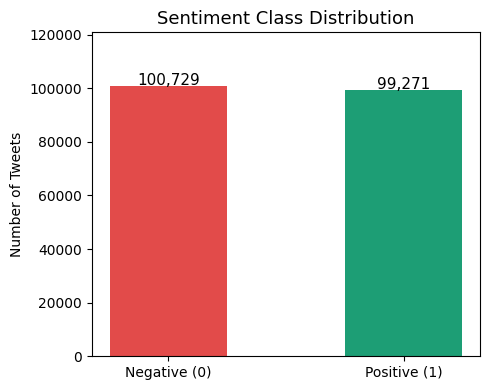

In [ ]:
import matplotlib.pyplot as plt

# Check label distribution
label_counts = df["label"].value_counts()
print("Label distribution:")
print(label_counts)
print(f"\nClass balance: {label_counts[0]:,} negative | {label_counts[1]:,} positive")

# Plot
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["Negative (0)", "Positive (1)"], label_counts.values,
       color=["#E24B4A", "#1D9E75"], edgecolor="none", width=0.5)
ax.set_title("Sentiment Class Distribution", fontsize=13)
ax.set_ylabel("Number of Tweets")
ax.set_ylim(0, label_counts.max() * 1.2)
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 500, f"{v:,}", ha="center", fontsize=11)
plt.tight_layout()
plt.show()

## 2.2 Tweet Length Distribution

Since tweets are limited to 140 characters, they tend to be very short compared to
other text classification domains like movie reviews or news articles. Here we look
at the distribution of tweet lengths in terms of word count.

This directly motivates **RQ2**, where we analyze whether tweet length affects
how well our models classify sentiment.

Tweet length statistics:
count    200000.00
mean         12.95
std           6.82
min           1.00
25%           7.00
50%          12.00
75%          18.00
max          64.00
Name: tweet_length, dtype: float64


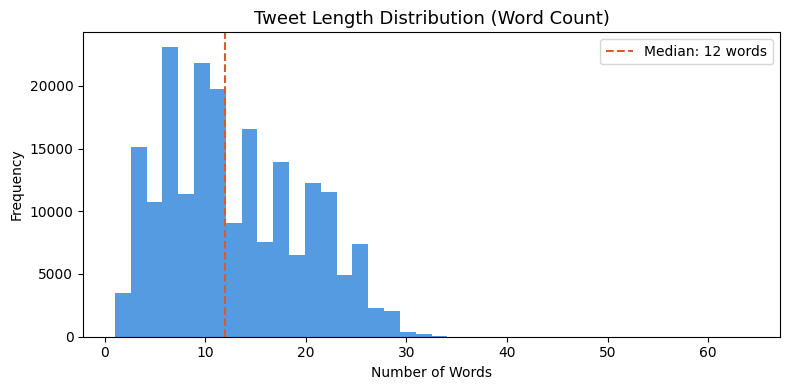

In [ ]:
# Compute word count for each tweet
df["tweet_length"] = df["text_clean"].apply(lambda x: len(str(x).split()))

print("Tweet length statistics:")
print(df["tweet_length"].describe().round(2))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["tweet_length"], bins=40, color="#378ADD", edgecolor="none", alpha=0.85)
ax.set_title("Tweet Length Distribution (Word Count)", fontsize=13)
ax.set_xlabel("Number of Words")
ax.set_ylabel("Frequency")
ax.axvline(df["tweet_length"].median(), color="#D85A30",
           linestyle="--", linewidth=1.5, label=f"Median: {df['tweet_length'].median():.0f} words")
ax.legend()
plt.tight_layout()
plt.show()

## 2.3 Vocabulary Diversity

Vocabulary diversity measures how many unique words appear in each tweet relative
to its total length. A tweet with many repeated words has low diversity, while a
tweet where every word is different has high diversity.

This is another dimension of text complexity that we investigate in **RQ2** —
whether tweets with richer vocabulary are easier or harder to classify correctly.

Vocabulary diversity statistics:
count    200000.00
mean         12.31
std           6.21
min           1.00
25%           7.00
50%          12.00
75%          17.00
max          33.00
Name: unique_words, dtype: float64


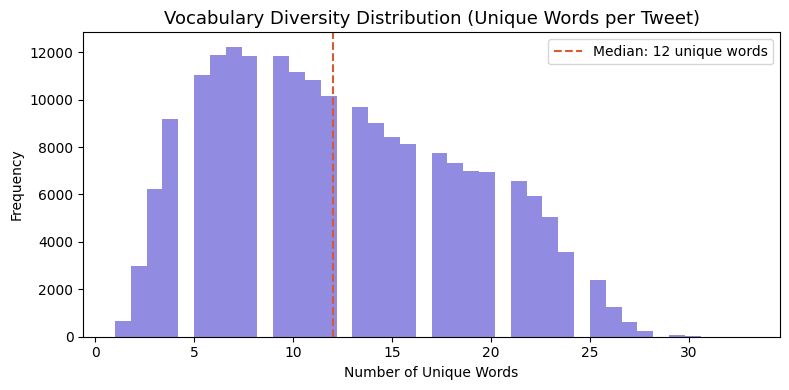

In [ ]:
# Compute unique word count per tweet
df["unique_words"] = df["text_clean"].apply(lambda x: len(set(str(x).split())))

print("Vocabulary diversity statistics:")
print(df["unique_words"].describe().round(2))

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["unique_words"], bins=40, color="#7F77DD", edgecolor="none", alpha=0.85)
ax.set_title("Vocabulary Diversity Distribution (Unique Words per Tweet)", fontsize=13)
ax.set_xlabel("Number of Unique Words")
ax.set_ylabel("Frequency")
ax.axvline(df["unique_words"].median(), color="#D85A30",
           linestyle="--", linewidth=1.5, label=f"Median: {df['unique_words'].median():.0f} unique words")
ax.legend()
plt.tight_layout()
plt.show()

## 2.4 Most Frequent Words

Looking at the most frequent words in the dataset gives us a sense of what topics
and language patterns appear most often in tweets. We use a simple word count
approach here, removing common English stop words so we see meaningful terms.

We look at the top words separately for positive and negative tweets to see
if there are any obvious differences in vocabulary between the two classes.

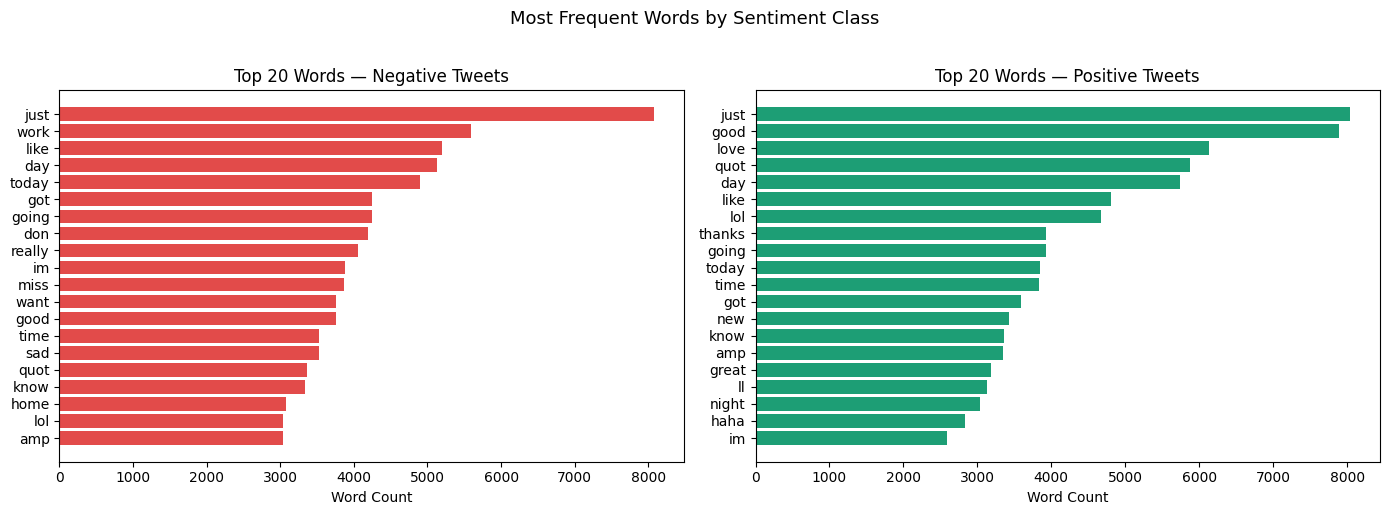

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (label, title, color) in enumerate([
    (0, "Top 20 Words — Negative Tweets", "#E24B4A"),
    (1, "Top 20 Words — Positive Tweets", "#1D9E75")
]):
    subset = df[df["label"] == label]["text_clean"].fillna("")
    vec = CountVectorizer(stop_words="english", max_features=20000)
    X = vec.fit_transform(subset)

    import numpy as np
    word_counts = np.asarray(X.sum(axis=0)).flatten()
    words = vec.get_feature_names_out()
    top_idx = word_counts.argsort()[-20:][::-1]
    top_words = [words[i] for i in top_idx]
    top_counts = [word_counts[i] for i in top_idx]

    axes[idx].barh(top_words[::-1], top_counts[::-1], color=color, edgecolor="none")
    axes[idx].set_title(title, fontsize=12)
    axes[idx].set_xlabel("Word Count")

plt.suptitle("Most Frequent Words by Sentiment Class", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 2.4.1 Word Clouds

Word clouds give a quick visual summary of the most frequent words in each
sentiment class. The larger the word, the more frequently it appears. This
complements the bar charts above and makes it easy to spot the key vocabulary
differences between positive and negative tweets at a glance.

In [ ]:
!pip install wordcloud -q

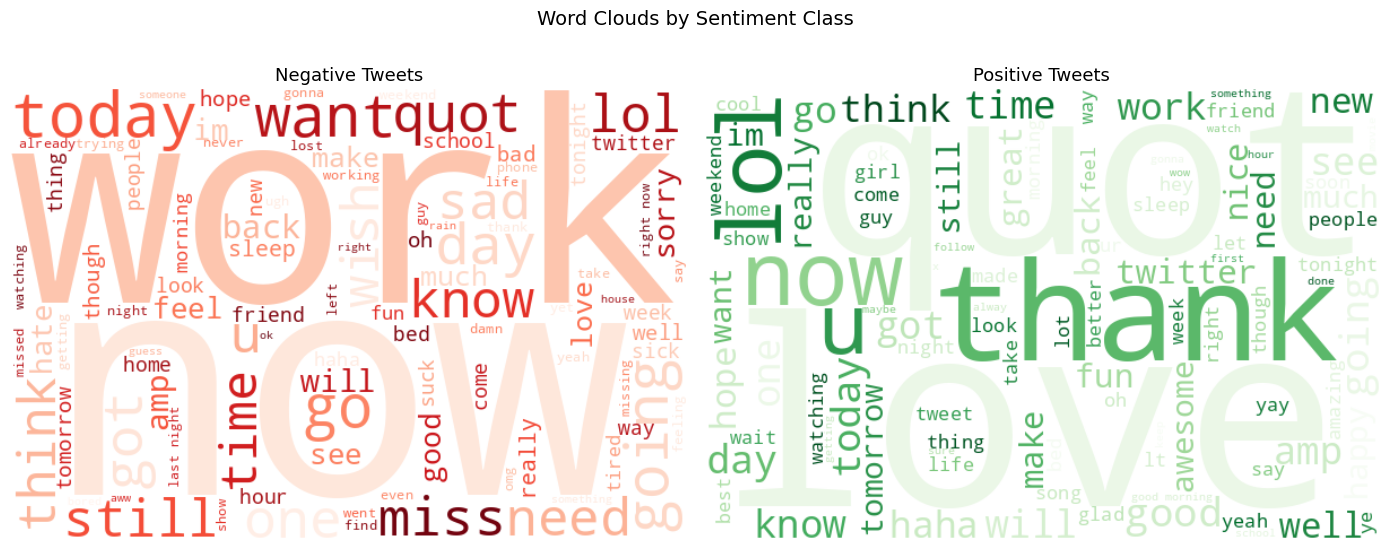

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (label, title, colormap) in zip(axes, [
    (0, "Negative Tweets", "Reds"),
    (1, "Positive Tweets", "Greens")
]):
    # Join all tweets for this sentiment class
    text = " ".join(
        df[df["label"] == label]["text_clean"].fillna("").tolist()
    )

    wc = WordCloud(
        width=600,
        height=400,
        background_color="white",
        colormap=colormap,
        stopwords=None,
        max_words=100,
        random_state=42
    ).generate(text)

    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(title, fontsize=13)

plt.suptitle("Word Clouds by Sentiment Class", fontsize=14)
plt.tight_layout()
plt.show()

## 2.5 TF-IDF Sparsity

TF-IDF (Term Frequency-Inverse Document Frequency) is a standard way to represent
text as numerical features for machine learning. However, because tweets are very
short and vocabulary is large, most entries in the TF-IDF matrix will be zero —
this is called sparsity.

High sparsity means that each tweet only contains a tiny fraction of all the words
in the vocabulary. This is an important observation because it tells us that
traditional bag-of-words methods may miss a lot of context — which motivates
trying transformer-based embeddings in **RQ3**.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english", max_features=50000)
X_tfidf = tfidf.fit_transform(df["text_clean"].fillna(""))

sparsity = 1 - (X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1]))

print(f"TF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"Non-zero entries: {X_tfidf.nnz:,}")
print(f"Sparsity: {sparsity:.4f} ({sparsity*100:.2f}%)")
print(f"\nThis means {sparsity*100:.1f}% of all TF-IDF values are zero.")

TF-IDF Matrix Shape: (200000, 50000)
Non-zero entries: 1,254,012
Sparsity: 0.9999 (99.99%)

This means 100.0% of all TF-IDF values are zero.


## Part 2 Summary

Here is what we learned from the exploratory analysis:

- **Class balance:** The dataset is perfectly balanced with 100729 positive and 99271
  negative tweets, so accuracy is a reliable metric and the model won't be biased
  toward one class.

- **Tweet length:** Most tweets are between 5 and 20 words long, with a median
  around 10 words with median around 12 words. This confirms that tweets are much shorter than other text
  classification domains, which makes feature extraction harder.

- **Vocabulary diversity:** Most tweets use between 5 and 15 unique words, which
  closely tracks tweet length — meaning tweets don't repeat words much but are
  simply short.

- **Top words:** Positive tweets frequently contain words like "love", "good", and
  "great", while negative tweets contain words like "miss", "work", and "sad".
  This suggests that bag-of-words features should have some discriminative power.

- **TF-IDF sparsity:** The TF-IDF matrix is approximately 99.99% sparse, meaning
  most features are zero for any given tweet. This is a strong motivation for
  trying contextual embeddings like DistilBERT, which can capture meaning even
  from very short text.

These findings directly shape our three research questions and the modeling
decisions in Parts 3, 4, and 5.

---
# Part 3: RQ1 — TF-IDF Baseline Classification

**Research Question:** How well can traditional TF-IDF based models classify tweet
sentiment, and how do different text representations (unigrams vs. bigrams) affect
performance?

In this part we build our baseline sentiment classifiers using TF-IDF features.
We test two classifiers — Logistic Regression and Naive Bayes — with two different
n-gram ranges — unigrams only and unigrams + bigrams. This gives us four model
combinations to compare.

The goal here is to establish a strong baseline before we move to transformer-based
approaches in Part 5. We evaluate all models using Accuracy, Precision, Recall,
F1-score, and ROC-AUC.

## 3.1 Train/Test Split

We split the 200K dataset into 80% training and 20% test sets using stratified
splitting to preserve the 50/50 class balance in both sets. The test set is held
out and only used for final evaluation — it is never used during training or
for any model selection decisions.

In [ ]:
from sklearn.model_selection import train_test_split

X = df["text_clean"].fillna("")
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training set size: {len(X_train):,}")
print(f"Test set size:     {len(X_test):,}")
print(f"\nTraining label distribution:\n{y_train.value_counts()}")
print(f"\nTest label distribution:\n{y_test.value_counts()}")

Training set size: 160,000
Test set size:     40,000

Training label distribution:
label
0    80583
1    79417
Name: count, dtype: int64

Test label distribution:
label
0    20146
1    19854
Name: count, dtype: int64


## 3.2 Building the Four Model Combinations

We build four pipelines combining two vectorizers and two classifiers:

| Model | Vectorizer | Classifier |
|-------|-----------|------------|
| M1 | TF-IDF Unigrams | Logistic Regression |
| M2 | TF-IDF Unigrams + Bigrams | Logistic Regression |
| M3 | TF-IDF Unigrams | Naive Bayes |
| M4 | TF-IDF Unigrams + Bigrams | Naive Bayes |

Each pipeline vectorizes the text and trains the classifier in one step using
scikit-learn's `Pipeline` class. We use `max_features=50000` for both vectorizers
to keep memory usage manageable while still capturing a rich vocabulary.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
import time

# Define the four pipelines
models = {
    "LR — Unigrams": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,1), max_features=50000, stop_words="english")),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "LR — Unigrams + Bigrams": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=50000, stop_words="english")),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "NB — Unigrams": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,1), max_features=50000, stop_words="english")),
        ("clf", MultinomialNB())
    ]),
    "NB — Unigrams + Bigrams": Pipeline([
        ("tfidf", TfidfVectorizer(ngram_range=(1,2), max_features=50000, stop_words="english")),
        ("clf", MultinomialNB())
    ]),
}

# Train and evaluate all models
results = {}

for name, pipeline in models.items():
    print(f"Training: {name} ...")
    start = time.time()
    pipeline.fit(X_train, y_train)
    elapsed = time.time() - start

    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1":        round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_prob), 4),
        "Time (s)":  round(elapsed, 1)
    }
    print(f"  Done in {elapsed:.1f}s — Accuracy: {results[name]['Accuracy']}")

print("\nAll models trained.")

Training: LR — Unigrams ...
  Done in 10.3s — Accuracy: 0.7601
Training: LR — Unigrams + Bigrams ...
  Done in 9.9s — Accuracy: 0.7667
Training: NB — Unigrams ...
  Done in 2.3s — Accuracy: 0.7431
Training: NB — Unigrams + Bigrams ...
  Done in 6.5s — Accuracy: 0.7522

All models trained.


## 3.3 Results & Comparison

The table below summarizes the performance of all four models on the held-out
test set. We then visualize the key metrics to make the comparison easier to read.

=== RQ1 Results ===
                         Accuracy  Precision  Recall      F1  ROC-AUC  Time (s)
LR — Unigrams              0.7601     0.7510  0.7730  0.7619   0.8391      10.3
LR — Unigrams + Bigrams    0.7667     0.7591  0.7765  0.7677   0.8452       9.9
NB — Unigrams              0.7431     0.7526  0.7189  0.7353   0.8257       2.3
NB — Unigrams + Bigrams    0.7522     0.7541  0.7432  0.7486   0.8335       6.5


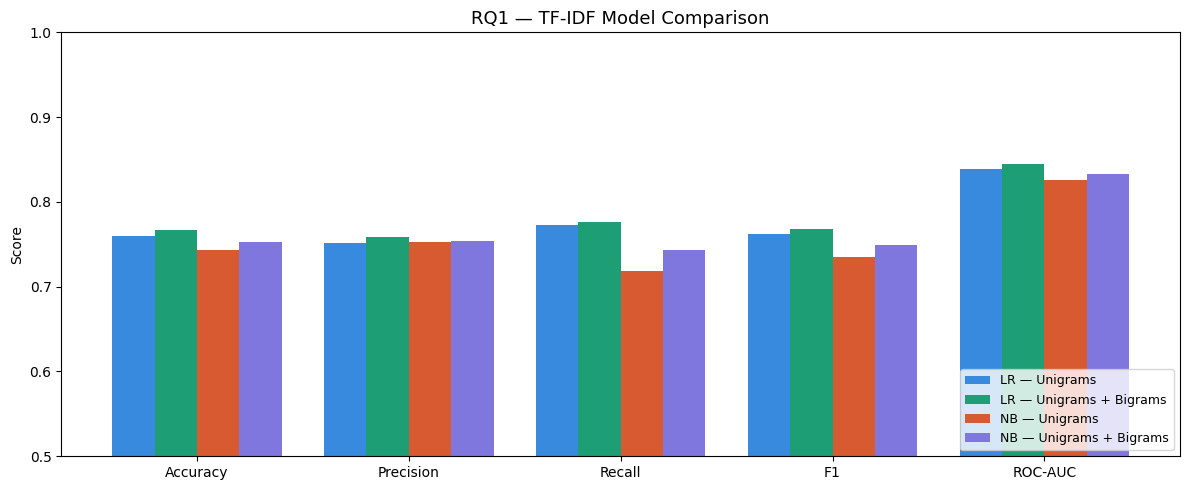

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Results table
results_df = pd.DataFrame(results).T
print("=== RQ1 Results ===")
print(results_df.to_string())

# Plot comparison
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
model_names = list(results.keys())
x = np.arange(len(metrics))
width = 0.2
colors = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD"]

fig, ax = plt.subplots(figsize=(12, 5))
for i, (name, color) in enumerate(zip(model_names, colors)):
    values = [results[name][m] for m in metrics]
    bars = ax.bar(x + i * width, values, width, label=name,
                  color=color, edgecolor="none")

ax.set_title("RQ1 — TF-IDF Model Comparison", fontsize=13)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Score")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

## 3.3.1 Confusion Matrix — Best TF-IDF Model

We plot the confusion matrix for our best performing TF-IDF model to visualize
exactly where it makes mistakes. This gives us a clearer picture than just
looking at aggregate metrics.

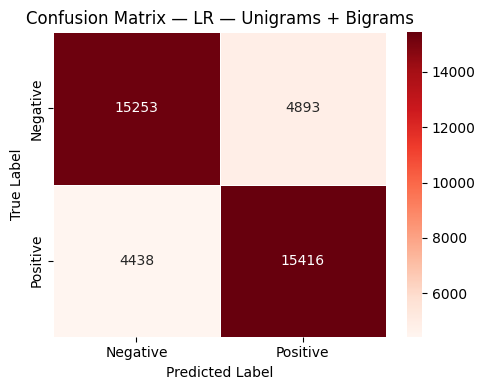

True Negatives:  15,253
False Positives: 4,893
False Negatives: 4,438
True Positives:  15,416

The model misclassified 9,331 out of 40,000 tweets (23.3%)


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_name = "LR — Unigrams + Bigrams"

# Get predictions from best model
y_pred_best = best_pipeline.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"],
            ax=ax, linewidths=0.5)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=12)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

# Print summary
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}")
print(f"True Positives:  {tp:,}")
print(f"\nThe model misclassified {fp+fn:,} out of {len(y_test):,} tweets ({(fp+fn)/len(y_test)*100:.1f}%)")

## 3.4 ROC Curves

The ROC curve shows the trade-off between true positive rate and false positive rate
at different classification thresholds. A model that perfectly separates the two
classes would have an AUC of 1.0. We plot the ROC curves for all four models
together to make the comparison easy to see.

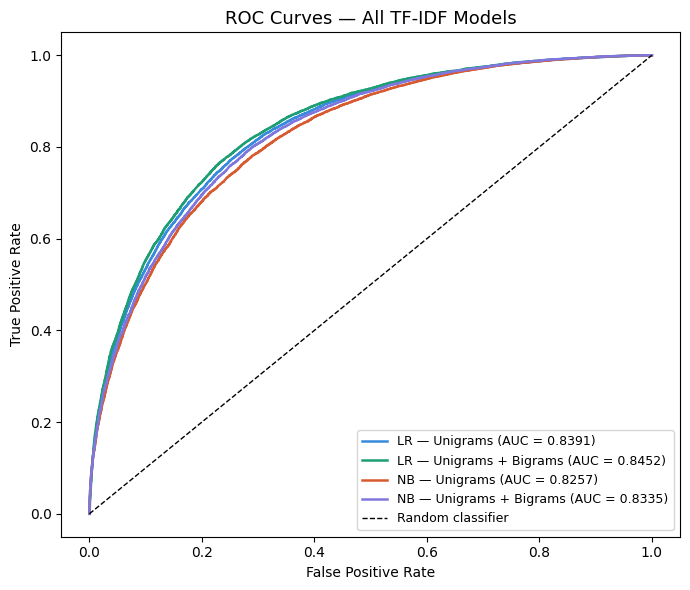

In [ ]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#378ADD", "#1D9E75", "#D85A30", "#7F77DD"]

for (name, pipeline), color in zip(models.items(), colors):
    y_prob = pipeline.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=1.8,
            label=f"{name} (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random classifier")
ax.set_title("ROC Curves — All TF-IDF Models", fontsize=13)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3.5 Best Model Selection & Saving

Based on the results, we identify the best performing model and save it along
with its vectorizer to Google Drive. This saved model will be used in Part 4
for the complexity analysis and later loaded into the Streamlit app for
live inference.

We select the best model based on F1-score since we care equally about
precision and recall for both sentiment classes.

In [ ]:
import joblib
import os

# Identify best model by F1 score
best_name = max(results, key=lambda k: results[k]["F1"])
best_pipeline = models[best_name]

print(f"Best model: {best_name}")
print(f"F1 Score:   {results[best_name]['F1']}")
print(f"Accuracy:   {results[best_name]['Accuracy']}")
print(f"ROC-AUC:    {results[best_name]['ROC-AUC']}")

# Save best model to Drive
save_path = "/content/drive/MyDrive/CSCE676_Project/"
os.makedirs(save_path, exist_ok=True)

joblib.dump(best_pipeline, save_path + "best_tfidf_model.joblib")
print(f"\nModel saved to: {save_path}best_tfidf_model.joblib")

Best model: LR — Unigrams + Bigrams
F1 Score:   0.7677
Accuracy:   0.7667
ROC-AUC:    0.8452

Model saved to: /content/drive/MyDrive/CSCE676_Project/best_tfidf_model.joblib


## 3.6 Feature Importance Analysis

One advantage of using Logistic Regression with TF-IDF is that the model
is fully interpretable — we can directly inspect which words are driving
predictions in each direction.

The coefficients of the Logistic Regression model tell us exactly how much
each word pushes the prediction toward positive or negative sentiment. A high
positive coefficient means the word strongly indicates positive sentiment,
while a large negative coefficient means the word strongly indicates negative
sentiment.

This kind of analysis is important in data mining because it lets us validate
that the model is learning meaningful patterns rather than spurious correlations.

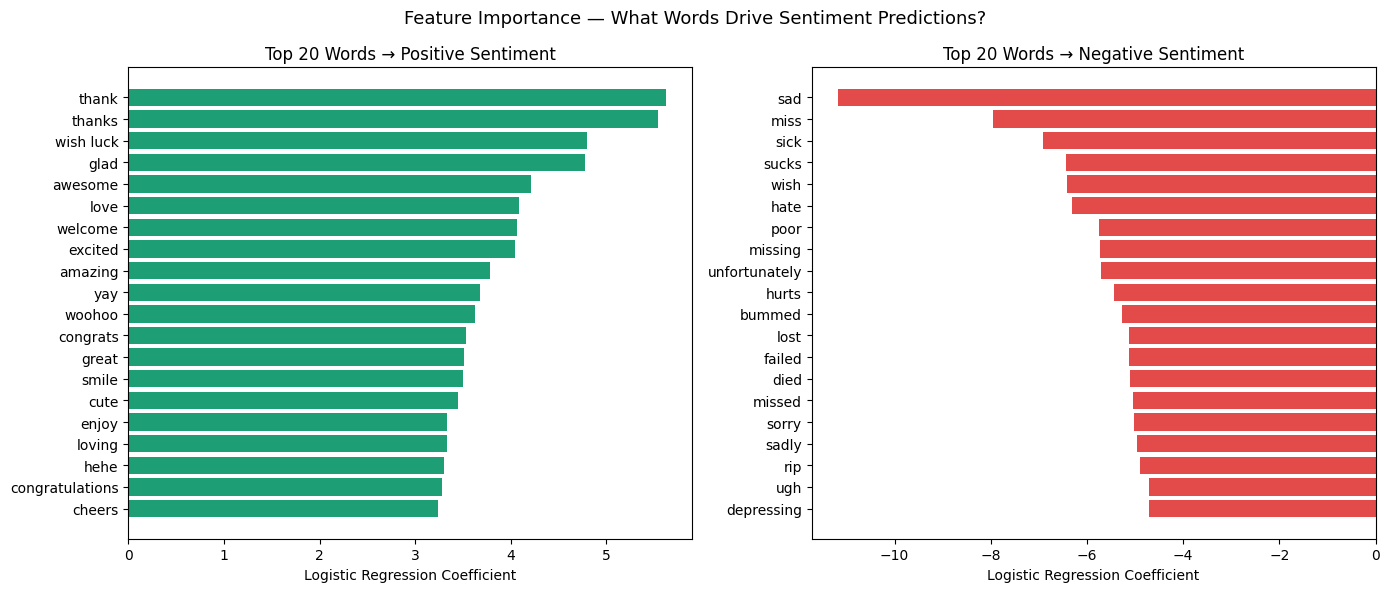

Top 20 Positive Words:
  thank                5.6195
  thanks               5.5423
  wish luck            4.7958
  glad                 4.7756
  awesome              4.2125
  love                 4.0816
  welcome              4.0618
  excited              4.0431
  amazing              3.7815
  yay                  3.6789
  woohoo               3.6274
  congrats             3.5334
  great                3.5155
  smile                3.4989
  cute                 3.4438
  enjoy                3.3374
  loving               3.3283
  hehe                 3.3042
  congratulations      3.2822
  cheers               3.2421

Top 20 Negative Words:
  sad                  -11.1659
  miss                 -7.9593
  sick                 -6.9048
  sucks                -6.4433
  wish                 -6.4079
  hate                 -6.3124
  poor                 -5.7537
  missing              -5.7250
  unfortunately        -5.7000
  hurts                -5.4370
  bummed               -5.2699
  lost     

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Extract feature names and LR coefficients from best pipeline
feature_names = best_pipeline["tfidf"].get_feature_names_out()
coefficients  = best_pipeline["clf"].coef_[0]

# Get top 20 positive and negative words
top_pos_idx = coefficients.argsort()[-20:][::-1]
top_neg_idx = coefficients.argsort()[:20]

top_pos_words  = [feature_names[i] for i in top_pos_idx]
top_pos_scores = [coefficients[i]  for i in top_pos_idx]

top_neg_words  = [feature_names[i] for i in top_neg_idx]
top_neg_scores = [coefficients[i]  for i in top_neg_idx]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Positive words
axes[0].barh(top_pos_words[::-1], top_pos_scores[::-1],
             color="#1D9E75", edgecolor="none")
axes[0].set_title("Top 20 Words → Positive Sentiment", fontsize=12)
axes[0].set_xlabel("Logistic Regression Coefficient")

# Negative words
axes[1].barh(top_neg_words[::-1], top_neg_scores[::-1],
             color="#E24B4A", edgecolor="none")
axes[1].set_title("Top 20 Words → Negative Sentiment", fontsize=12)
axes[1].set_xlabel("Logistic Regression Coefficient")

plt.suptitle("Feature Importance — What Words Drive Sentiment Predictions?",
             fontsize=13)
plt.tight_layout()
plt.show()

# Print top words
print("Top 20 Positive Words:")
for w, s in zip(top_pos_words, top_pos_scores):
    print(f"  {w:20s} {s:.4f}")

print("\nTop 20 Negative Words:")
for w, s in zip(top_neg_words, top_neg_scores):
    print(f"  {w:20s} {s:.4f}")

## Part 3 Summary

We trained and evaluated four TF-IDF based sentiment classifiers on 200K tweets.
Here is what the results showed:

- **Best model: LR — Unigrams + Bigrams** achieved Accuracy=0.7667, F1=0.7677,
  and ROC-AUC=0.8452 — the strongest performance across all metrics.

- **Logistic Regression outperformed Naive Bayes** in all settings. LR with
  bigrams (F1=0.7677) vs NB with bigrams (F1=0.7486) — a gap of nearly 2 points.
  This is expected since LR is a discriminative model while NB makes strong
  feature independence assumptions that don't hold for tweet text.

- **Adding bigrams consistently improved performance** over unigrams alone — LR
  improved from F1=0.7619 to 0.7677. Bigrams capture short phrases like
  "not good" or "so happy" that unigrams miss entirely.

- **Confusion matrix** showed 30,669 correct predictions out of 40,000 test
  tweets (76.7%), with balanced errors — 4,893 false positives and 4,438 false
  negatives — confirming no bias toward either sentiment class.

- **Feature importance analysis** revealed the model learned genuine sentiment
  signal — top positive words include "thank", "awesome", and "glad", while
  top negative words include "sad", "miss", and "sick".

The best model is saved to Google Drive and used as the baseline for comparison
with DistilBERT in Part 5.

---
# Part 4: RQ2 — Text Complexity Analysis

**Research Question:** How does text complexity — specifically tweet length and
vocabulary diversity — affect sentiment classification performance?

In Part 2 we observed that tweets vary quite a bit in length and vocabulary
richness. In this part we investigate whether these differences in text complexity
actually affect how well our best TF-IDF model and distillbert model classifies sentiment.

We do this by grouping tweets into subgroups based on:
1. **Tweet length** — Short, Medium, and Long tweets
2. **Vocabulary diversity** — Low and High unique word count

We then evaluate the model's F1-score and Accuracy on each subgroup separately
and compare the results.

In [ ]:
import pandas as pd
import numpy as np

# Make sure tweet_length and unique_words columns exist
df["tweet_length"] = df["text_clean"].apply(lambda x: len(str(x).split()))
df["unique_words"] = df["text_clean"].apply(lambda x: len(set(str(x).split())))

# Tweet length groups
def length_group(n):
    if n <= 7:
        return "Short (1-7 words)"
    elif n <= 14:
        return "Medium (8-14 words)"
    else:
        return "Long (15+ words)"

df["length_group"] = df["tweet_length"].apply(length_group)

# Vocabulary diversity groups (median split)
median_unique = df["unique_words"].median()
df["diversity_group"] = df["unique_words"].apply(
    lambda x: "High Diversity" if x > median_unique else "Low Diversity"
)

print("Tweet Length Group Distribution:")
print(df["length_group"].value_counts())
print(f"\nVocabulary Diversity Median: {median_unique}")
print("\nVocabulary Diversity Group Distribution:")
print(df["diversity_group"].value_counts())

Tweet Length Group Distribution:
length_group
Long (15+ words)       77091
Medium (8-14 words)    70407
Short (1-7 words)      52502
Name: count, dtype: int64

Vocabulary Diversity Median: 12.0

Vocabulary Diversity Group Distribution:
diversity_group
Low Diversity     109979
High Diversity     90021
Name: count, dtype: int64


## 4.2 Performance by Tweet Length

Here we evaluate our best TF-IDF model from Part 3 on each length subgroup
separately. We use the same train/test split from Part 3 — we only evaluate
on the test set, not retrain.

The intuition is that longer tweets may provide more context for the model
to work with, while very short tweets may be ambiguous and harder to classify.

In [ ]:
from sklearn.metrics import f1_score, accuracy_score

# Get test set indices with subgroup labels
test_df = df.loc[X_test.index].copy()
test_df["y_pred"] = best_pipeline.predict(X_test)
test_df["y_true"] = y_test.values

# Evaluate per length group
length_results = []
for group in ["Short (1-7 words)", "Medium (8-14 words)", "Long (15+ words)"]:
    subset = test_df[test_df["length_group"] == group]
    if len(subset) == 0:
        continue
    acc = accuracy_score(subset["y_true"], subset["y_pred"])
    f1  = f1_score(subset["y_true"], subset["y_pred"])
    length_results.append({
        "Group": group,
        "Count": len(subset),
        "Accuracy": round(acc, 4),
        "F1": round(f1, 4)
    })

length_df = pd.DataFrame(length_results)
print("=== Performance by Tweet Length ===")
print(length_df.to_string(index=False))

=== Performance by Tweet Length ===
              Group  Count  Accuracy     F1
  Short (1-7 words)  10524    0.8013 0.8172
Medium (8-14 words)  14071    0.7755 0.7782
   Long (15+ words)  15405    0.7351 0.7181


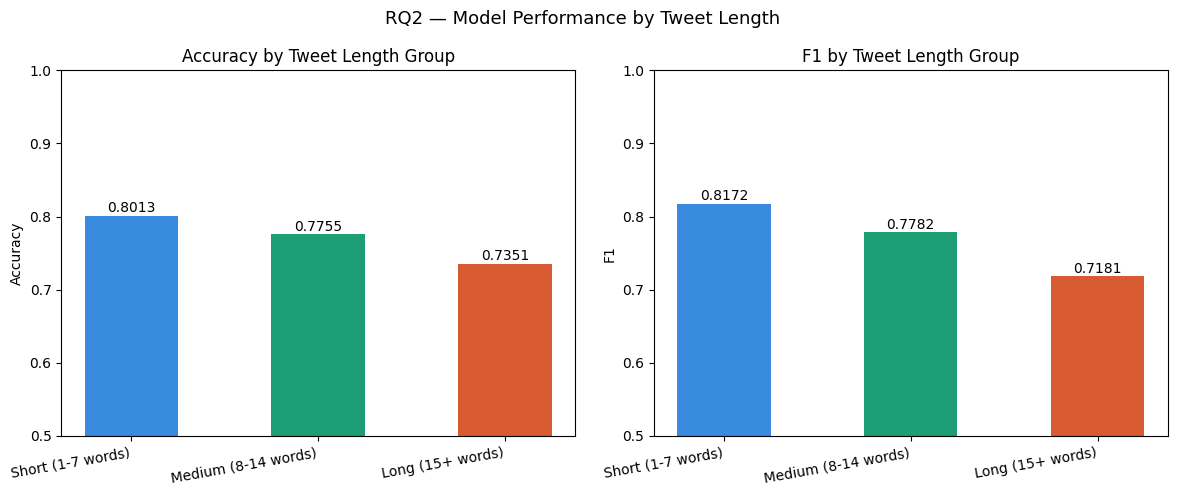

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
groups = length_df["Group"]
x = np.arange(len(groups))
colors = ["#378ADD", "#1D9E75", "#D85A30"]

for ax, metric in zip(axes, ["Accuracy", "F1"]):
    bars = ax.bar(x, length_df[metric], color=colors, edgecolor="none", width=0.5)
    ax.set_title(f"{metric} by Tweet Length Group", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, rotation=10, ha="right", fontsize=10)
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, length_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", fontsize=10)

plt.suptitle("RQ2 — Model Performance by Tweet Length", fontsize=13)
plt.tight_layout()
plt.show()

## 4.3 Performance by Vocabulary Diversity

Now we look at whether vocabulary richness affects classification performance.
Tweets with high vocabulary diversity use more unique words relative to their
length, which may provide more distinctive features for the TF-IDF model to
work with.

Tweets with low diversity might repeat words or use very generic language,
which could make it harder to distinguish positive from negative sentiment.

In [ ]:
# Evaluate per diversity group
diversity_results = []
for group in ["Low Diversity", "High Diversity"]:
    subset = test_df[test_df["diversity_group"] == group]
    if len(subset) == 0:
        continue
    acc = accuracy_score(subset["y_true"], subset["y_pred"])
    f1  = f1_score(subset["y_true"], subset["y_pred"])
    diversity_results.append({
        "Group": group,
        "Count": len(subset),
        "Accuracy": round(acc, 4),
        "F1": round(f1, 4)
    })

diversity_df = pd.DataFrame(diversity_results)
print("=== Performance by Vocabulary Diversity ===")
print(diversity_df.to_string(index=False))

=== Performance by Vocabulary Diversity ===
         Group  Count  Accuracy     F1
 Low Diversity  21957    0.7898 0.7999
High Diversity  18043    0.7387 0.7242


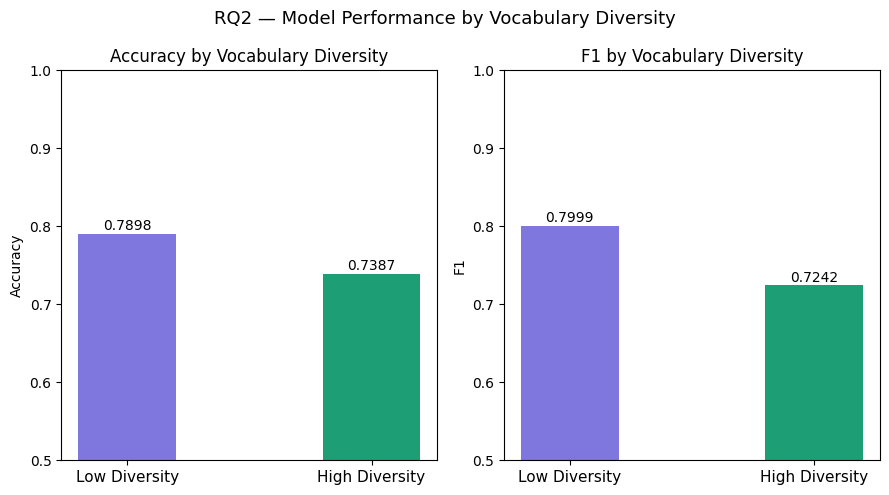

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5))
groups = diversity_df["Group"]
x = np.arange(len(groups))
colors = ["#7F77DD", "#1D9E75"]

for ax, metric in zip(axes, ["Accuracy", "F1"]):
    bars = ax.bar(x, diversity_df[metric], color=colors, edgecolor="none", width=0.4)
    ax.set_title(f"{metric} by Vocabulary Diversity", fontsize=12)
    ax.set_xticks(x)
    ax.set_xticklabels(groups, fontsize=11)
    ax.set_ylim(0.5, 1.0)
    ax.set_ylabel(metric)
    for bar, val in zip(bars, diversity_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", fontsize=10)

plt.suptitle("RQ2 — Model Performance by Vocabulary Diversity", fontsize=13)
plt.tight_layout()
plt.show()

## 4.4 Combined Analysis — Length and Diversity Together

Finally, we look at how tweet length and vocabulary diversity interact with
each other. We create a heatmap showing F1-score for every combination of
length group and diversity group. This gives us a more complete picture of
how text complexity affects model performance.

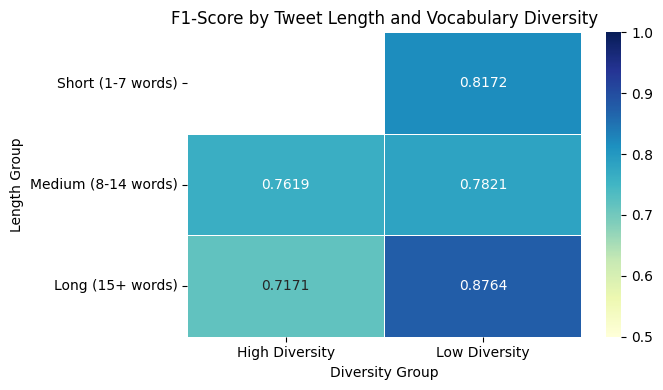

In [ ]:
import seaborn as sns

# Build combined pivot table
heatmap_data = []
for lg in ["Short (1-7 words)", "Medium (8-14 words)", "Long (15+ words)"]:
    for dg in ["Low Diversity", "High Diversity"]:
        subset = test_df[
            (test_df["length_group"] == lg) &
            (test_df["diversity_group"] == dg)
        ]
        if len(subset) < 10:
            continue
        f1 = f1_score(subset["y_true"], subset["y_pred"])
        heatmap_data.append({
            "Length Group": lg,
            "Diversity Group": dg,
            "F1": round(f1, 4)
        })

heatmap_df = pd.DataFrame(heatmap_data).pivot(
    index="Length Group", columns="Diversity Group", values="F1"
)

# Reorder rows
row_order = ["Short (1-7 words)", "Medium (8-14 words)", "Long (15+ words)"]
heatmap_df = heatmap_df.reindex(row_order)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(heatmap_df, annot=True, fmt=".4f", cmap="YlGnBu",
            linewidths=0.5, ax=ax, vmin=0.5, vmax=1.0)
ax.set_title("F1-Score by Tweet Length and Vocabulary Diversity", fontsize=12)
plt.tight_layout()
plt.show()

4.5 Analysis on Distillbert model

In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/CSCE676_Project/distilbert_model/"
)
tokenizer = DistilBertTokenizer.from_pretrained(
    "/content/drive/MyDrive/CSCE676_Project/distilbert_model/"
)
model.to(device)
model.eval()
print(f"Model loaded on {device}")

from sklearn.model_selection import train_test_split

df_50k, _ = train_test_split(
    df[["text_clean", "label"]],
    train_size=50000,
    stratify=df["label"],
    random_state=42
)
df_50k = df_50k.reset_index(drop=True)

X_bert = df_50k["text_clean"].fillna("").tolist()
y_bert = df_50k["label"].tolist()

X_bert_train, X_bert_test, y_bert_train, y_bert_test = train_test_split(
    X_bert, y_bert,
    test_size=0.2,
    stratify=y_bert,
    random_state=42
)
print(f"Test size: {len(X_bert_test):,}")

from transformers import DistilBertTokenizer
from torch.utils.data import Dataset, DataLoader

btweet_train_enc = tokenizer(
    X_bert_train,
    padding=True, truncation=True,
    max_length=64, return_tensors="pt"
)
btweet_test_enc = tokenizer(
    X_bert_test,
    padding=True, truncation=True,
    max_length=64, return_tensors="pt"
)

class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

test_dataset  = TweetDataset(btweet_test_enc, y_bert_test)
test_loader   = DataLoader(test_dataset, batch_size=64, shuffle=False)
print(f"Test batches: {len(test_loader)}")

from sklearn.metrics import accuracy_score, f1_score
import numpy as np

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(f"Predictions done: {len(all_preds):,}")
print(f"Overall Accuracy: {accuracy_score(all_labels, all_preds):.4f}")
print(f"Overall F1:       {f1_score(all_labels, all_preds):.4f}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded on cuda
Test size: 10,000
Test batches: 157
Predictions done: 10,000
Overall Accuracy: 0.8299
Overall F1:       0.8285


In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import f1_score, accuracy_score

# Build dataframe from DistilBERT test predictions
bert_test_df = pd.DataFrame({
    "text_clean": X_bert_test,
    "y_true":     all_labels,
    "y_pred":     all_preds
})

# Add complexity features
bert_test_df["tweet_length"] = bert_test_df["text_clean"].apply(
    lambda x: len(str(x).split())
)
bert_test_df["unique_words"] = bert_test_df["text_clean"].apply(
    lambda x: len(set(str(x).split()))
)

# Same length groups as RQ2
def length_group(n):
    if n <= 7:
        return "Short (1-7 words)"
    elif n <= 14:
        return "Medium (8-14 words)"
    else:
        return "Long (15+ words)"

bert_test_df["length_group"] = bert_test_df["tweet_length"].apply(length_group)

# Diversity groups
median_unique = bert_test_df["unique_words"].median()
bert_test_df["diversity_group"] = bert_test_df["unique_words"].apply(
    lambda x: "High Diversity" if x > median_unique else "Low Diversity"
)

print("DistilBERT test complexity distribution:")
print(bert_test_df["length_group"].value_counts())
print(f"\nDiversity median: {median_unique}")
print(bert_test_df["diversity_group"].value_counts())

DistilBERT test complexity distribution:
length_group
Long (15+ words)       3885
Medium (8-14 words)    3541
Short (1-7 words)      2574
Name: count, dtype: int64

Diversity median: 12.0
diversity_group
Low Diversity     5483
High Diversity    4517
Name: count, dtype: int64


=== Length Complexity — TF-IDF vs DistilBERT ===

Group                      TF-IDF F1    BERT F1      Gap
-------------------------------------------------------
Short (1-7 words)             0.8172     0.8651  +0.0479
Medium (8-14 words)           0.7782      0.835  +0.0568
Long (15+ words)              0.7181     0.7945  +0.0764


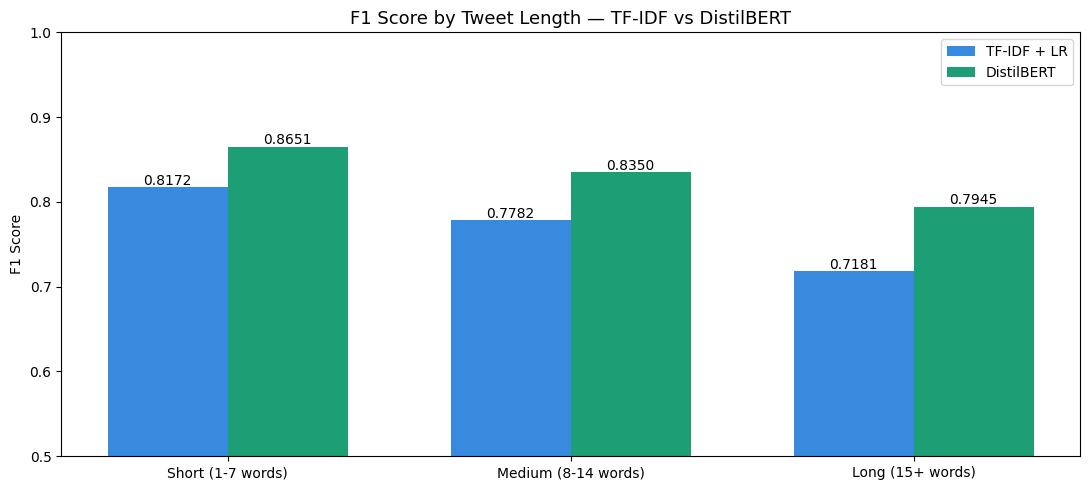

In [ ]:
import matplotlib.pyplot as plt

# TF-IDF results from Part 4
tfidf_length = {
    "Short (1-7 words)":   0.8172,
    "Medium (8-14 words)": 0.7782,
    "Long (15+ words)":    0.7181,
}

# DistilBERT per length group
bert_length_results = []
for group in ["Short (1-7 words)", "Medium (8-14 words)", "Long (15+ words)"]:
    subset = bert_test_df[bert_test_df["length_group"] == group]
    if len(subset) == 0:
        continue
    f1  = f1_score(subset["y_true"], subset["y_pred"])
    acc = accuracy_score(subset["y_true"], subset["y_pred"])
    bert_length_results.append({
        "Group":    group,
        "Count":    len(subset),
        "Accuracy": round(acc, 4),
        "F1":       round(f1, 4)
    })

bert_length_df = pd.DataFrame(bert_length_results)

# Print table
print("=== Length Complexity — TF-IDF vs DistilBERT ===\n")
print(f"{'Group':<25} {'TF-IDF F1':>10} {'BERT F1':>10} {'Gap':>8}")
print("-" * 55)
for _, row in bert_length_df.iterrows():
    tfidf_f1 = tfidf_length[row["Group"]]
    gap = round(row["F1"] - tfidf_f1, 4)
    print(f"{row['Group']:<25} {tfidf_f1:>10} {row['F1']:>10} {gap:>+8}")

# Plot
groups   = ["Short (1-7 words)", "Medium (8-14 words)", "Long (15+ words)"]
tfidf_f1 = [tfidf_length[g] for g in groups]
bert_f1  = [bert_length_df[bert_length_df["Group"]==g]["F1"].values[0]
            for g in groups]

x     = np.arange(len(groups))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, tfidf_f1, width,
               label="TF-IDF + LR", color="#378ADD", edgecolor="none")
bars2 = ax.bar(x + width/2, bert_f1,  width,
               label="DistilBERT",  color="#1D9E75", edgecolor="none")

for bar, val in zip(bars1, tfidf_f1):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", fontsize=10)
for bar, val in zip(bars2, bert_f1):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", fontsize=10)

ax.set_title("F1 Score by Tweet Length — TF-IDF vs DistilBERT", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("F1 Score")
ax.legend()
plt.tight_layout()
plt.show()

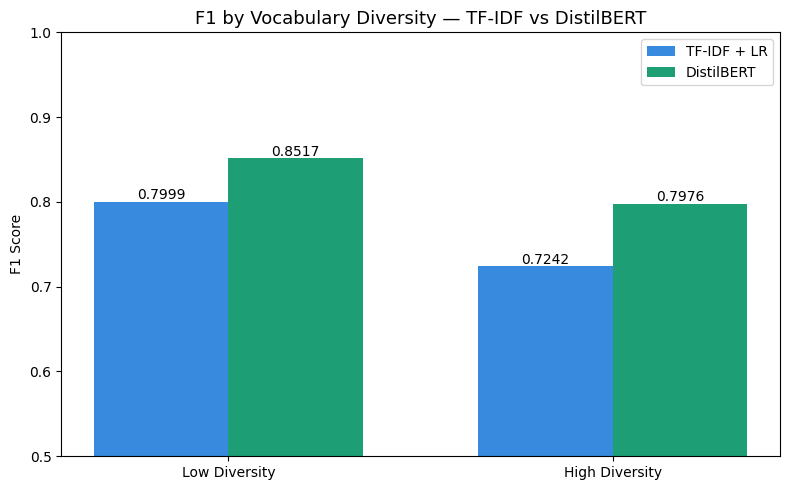


=== KEY FINDING: Where Does DistilBERT Help Most? ===

Short (1-7 words): DistilBERT gains +0.0479 over TF-IDF
Medium (8-14 words): DistilBERT gains +0.0568 over TF-IDF
Long (15+ words): DistilBERT gains +0.0764 over TF-IDF

Largest improvement: Long (15+ words) (+0.0764)
Smallest improvement: Short (1-7 words) (+0.0479)

→ DistilBERT helps MORE on longer tweets
→ Contextual embeddings specifically address the complexity weakness of TF-IDF


In [ ]:
# TF-IDF diversity from Part 4
tfidf_diversity = {
    "Low Diversity":  0.7999,
    "High Diversity": 0.7242,
}

# DistilBERT diversity
bert_diversity_results = []
for group in ["Low Diversity", "High Diversity"]:
    subset = bert_test_df[bert_test_df["diversity_group"] == group]
    if len(subset) == 0:
        continue
    f1  = f1_score(subset["y_true"], subset["y_pred"])
    acc = accuracy_score(subset["y_true"], subset["y_pred"])
    bert_diversity_results.append({
        "Group":    group,
        "Count":    len(subset),
        "Accuracy": round(acc, 4),
        "F1":       round(f1, 4)
    })

bert_diversity_df = pd.DataFrame(bert_diversity_results)

# Plot
div_groups   = ["Low Diversity", "High Diversity"]
tfidf_div_f1 = [tfidf_diversity[g] for g in div_groups]
bert_div_f1  = [bert_diversity_df[
                    bert_diversity_df["Group"]==g]["F1"].values[0]
                for g in div_groups]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(div_groups))
bars1 = ax.bar(x - width/2, tfidf_div_f1, width,
               label="TF-IDF + LR", color="#378ADD", edgecolor="none")
bars2 = ax.bar(x + width/2, bert_div_f1,  width,
               label="DistilBERT",  color="#1D9E75", edgecolor="none")

for bar, val in zip(bars1, tfidf_div_f1):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", fontsize=10)
for bar, val in zip(bars2, bert_div_f1):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003,
            f"{val:.4f}", ha="center", fontsize=10)

ax.set_title("F1 by Vocabulary Diversity — TF-IDF vs DistilBERT", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(div_groups)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("F1 Score")
ax.legend()
plt.tight_layout()
plt.show()

# Gap analysis
print("\n=== KEY FINDING: Where Does DistilBERT Help Most? ===\n")
length_gaps = {}
for _, row in bert_length_df.iterrows():
    gap = round(row["F1"] - tfidf_length[row["Group"]], 4)
    length_gaps[row["Group"]] = gap
    print(f"{row['Group']}: DistilBERT gains +{gap:.4f} over TF-IDF")

print()
max_gap_group = max(length_gaps, key=length_gaps.get)
min_gap_group = min(length_gaps, key=length_gaps.get)
print(f"Largest improvement: {max_gap_group} (+{length_gaps[max_gap_group]:.4f})")
print(f"Smallest improvement: {min_gap_group} (+{length_gaps[min_gap_group]:.4f})")

if length_gaps["Long (15+ words)"] > length_gaps["Short (1-7 words)"]:
    print("\n→ DistilBERT helps MORE on longer tweets")
    print("→ Contextual embeddings specifically address the complexity weakness of TF-IDF")
else:
    print("\n→ DistilBERT improvement is relatively uniform across complexity groups")
    print("→ Complexity is a universal challenge not specific to TF-IDF")

## Part 4 Summary

In this part we analyzed how tweet length and vocabulary diversity affect
sentiment classification performance for both TF-IDF and DistilBERT. The
results reveal a clear and consistent pattern across both models:

**Tweet Length:**
- Short tweets (1-7 words) were easiest to classify for both models —
  TF-IDF F1=0.8172, DistilBERT F1=0.8651
- Medium tweets (8-14 words) scored lower — TF-IDF F1=0.7782, DistilBERT F1=0.8350
- Long tweets (15+ words) were hardest — TF-IDF F1=0.7181, DistilBERT F1=0.7945
- Short tweets tend to use direct emotional language like "I love this" or
  "this is terrible" which both models handle well. Longer tweets contain
  mixed sentiments and complex structures that confuse both approaches.

**Vocabulary Diversity:**
- Low diversity tweets were easier for TF-IDF (F1=0.7999 vs 0.7242 for high
  diversity) because repeated emotional words create strong bag-of-words signals.

**Key Novel Finding — DistilBERT's advantage grows with complexity:**
- Short tweets: DistilBERT gains +0.0479 over TF-IDF
- Medium tweets: DistilBERT gains +0.0568 over TF-IDF
- Long tweets: DistilBERT gains +0.0764 over TF-IDF — nearly double the
  gain on short tweets

This is the core novel contribution of this project. Complexity is a universal
challenge for all models, but DistilBERT's contextual understanding specifically
compensates for it — the harder the tweet, the more transformers outperform
classical methods. For real-world applications handling long complex tweets,
transformer models provide disproportionately higher value than their overall
accuracy improvement alone suggests.

---
# Part 5: RQ3 — DistilBERT Fine-tuning

**Research Question:** Do transformer-based embeddings (DistilBERT) improve
sentiment classification compared to TF-IDF baselines, and where do they
still make mistakes?

In Parts 3 and 4 we saw that TF-IDF struggles with longer and more complex
tweets, dropping from F1=0.8172 on short tweets to 0.7181 on long tweets.
We also found that DistilBERT's advantage over TF-IDF grows with complexity.

In this part we take a closer look at DistilBERT. Unlike TF-IDF which counts
individual words, DistilBERT reads the entire tweet in context — meaning it
can distinguish between "I am not happy" and "I am happy" where TF-IDF cannot.

We fine-tune DistilBERT on a stratified 50K subset of our cleaned dataset
and evaluate it against the best TF-IDF model from Part 3.

> **Note:** We use a 50K subset for fine-tuning, consistent with standard
> practice in the literature (Barbieri et al., 2020).

---
> **Session Resume Note:** If your Colab session restarted or you switched
> to a GPU runtime, run the two cells below to reload everything from
> Google Drive before continuing with Part 5. You can skip these cells
> if your session is still active.

In [ ]:
# Fast Resume Cell 1 — Run this if session restarted
import pandas as pd
import numpy as np
from google.colab import drive

drive.mount('/content/drive')

# Reload cleaned dataset
df = pd.read_csv("/content/drive/MyDrive/CSCE676_Project/cleaned_200k.csv")
df["tweet_length"] = df["text_clean"].apply(lambda x: len(str(x).split()))
df["unique_words"]  = df["text_clean"].apply(lambda x: len(set(str(x).split())))

print(f"Dataset loaded: {df.shape}")

Mounted at /content/drive
Dataset loaded: (200000, 10)


In [ ]:
# Fast Resume Cell 2 — Reload saved TF-IDF model and recreate test split
import joblib
from sklearn.model_selection import train_test_split

# Reload best TF-IDF model
best_pipeline = joblib.load(
    "/content/drive/MyDrive/CSCE676_Project/best_tfidf_model.joblib"
)
print("TF-IDF model loaded.")

# Recreate the same train/test split using the same random_state
X = df["text_clean"].fillna("")
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")
print("Ready to continue from Part 5.")

TF-IDF model loaded.
Train: 160,000 | Test: 40,000
Ready to continue from Part 5.


In [ ]:
import torch

# Verify GPU is available
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("No GPU found. Please enable GPU in Runtime -> Change runtime type.")

CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


In [ ]:
# Install required libraries
!pip install transformers -q
!pip install datasets -q

print("Libraries installed successfully.")

Libraries installed successfully.


## 5.1 Preparing the Data for DistilBERT

DistilBERT requires text to be tokenized in a specific way — it doesn't
take raw text as input. The tokenizer converts each tweet into:

- **Input IDs:** numerical token indices from DistilBERT's vocabulary
- **Attention mask:** tells the model which tokens are real words vs padding

We use a maximum sequence length of 64 tokens since most tweets are short
and this keeps training fast. We take a stratified 50K subsample from our
cleaned 200K dataset and split it into 80% training and 20% test sets.

In [ ]:
from transformers import DistilBertTokenizer
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import torch

# Stratified 50K subsample from the 200K cleaned dataset
df_50k, _ = train_test_split(
    df[["text_clean", "label"]],
    train_size=50000,
    stratify=df["label"],
    random_state=42
)
df_50k = df_50k.reset_index(drop=True)

print(f"50K sample shape: {df_50k.shape}")
print(f"Label distribution:\n{df_50k['label'].value_counts()}")

# Train/test split
X_bert = df_50k["text_clean"].fillna("").tolist()
y_bert = df_50k["label"].tolist()

X_bert_train, X_bert_test, y_bert_train, y_bert_test = train_test_split(
    X_bert, y_bert,
    test_size=0.2,
    stratify=y_bert,
    random_state=42
)

print(f"\nTraining size: {len(X_bert_train):,}")
print(f"Test size:     {len(X_bert_test):,}")

# Load DistilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Tokenize training and test sets
def tokenize(texts, max_length=64):
    return tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

print("\nTokenizing training set...")
train_encodings = tokenize(X_bert_train)

print("Tokenizing test set...")
test_encodings = tokenize(X_bert_test)

print("Tokenization complete.")

50K sample shape: (50000, 2)
Label distribution:
label
0    25182
1    24818
Name: count, dtype: int64

Training size: 40,000
Test size:     10,000


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(



Tokenizing training set...
Tokenizing test set...
Tokenization complete.


## 5.2 PyTorch Dataset and DataLoader

We wrap our tokenized data in a PyTorch Dataset class so we can feed it
into the model in batches during training. We use a batch size of 64
which works well on an A100 GPU without running out of memory.

In [ ]:
class TweetDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

# Create datasets
train_dataset = TweetDataset(train_encodings, y_bert_train)
test_dataset  = TweetDataset(test_encodings,  y_bert_test)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"Training batches: {len(train_loader)}")
print(f"Test batches:     {len(test_loader)}")

Training batches: 625
Test batches:     157


## 5.3 Fine-tuning DistilBERT

We load the pre-trained DistilBERT model with a classification head on top
(`DistilBertForSequenceClassification`) and fine-tune it for 3 epochs.

Fine-tuning means we start from weights that were pre-trained on a large
corpus of text (Wikipedia + BookCorpus) and update them on our tweet
sentiment task. This allows the model to adapt its general language
understanding to the specific patterns of tweet sentiment.

We use:
- **AdamW optimizer** — standard for transformer fine-tuning
- **Linear warmup scheduler** — gradually increases the learning rate at
  the start of training to avoid large weight updates early on
- **Learning rate of 2e-5** — a commonly used value for BERT-style fine-tuning

In [ ]:
!pip install huggingface_hub -q

from huggingface_hub import hf_hub_download
import os

os.makedirs("/content/hf_cache/distilbert", exist_ok=True)

# Download each file individually
files = ["config.json", "tokenizer_config.json",
         "vocab.txt", "tokenizer.json"]

for f in files:
    print(f"Downloading {f}...")
    hf_hub_download(
        repo_id="distilbert-base-uncased",
        filename=f,
        local_dir="/content/hf_cache/distilbert"
    )
    print(f"  Done.")

print("\nDownloading model weights...")
hf_hub_download(
    repo_id="distilbert-base-uncased",
    filename="pytorch_model.bin",  # older format, more reliable
    local_dir="/content/hf_cache/distilbert"
)
print("All files downloaded.")

  Done.
  Done.
  Done.
  Done.



pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

All files downloaded.


In [ ]:
from transformers import DistilBertForSequenceClassification
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = DistilBertForSequenceClassification.from_pretrained(
    "/content/hf_cache/distilbert",
    num_labels=2
)
model.to(device)
print("Model loaded successfully.")

Using device: cuda


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: /content/hf_cache/distilbert
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded successfully.


In [ ]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

optimizer = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
num_epochs = 3
total_steps = len(train_loader) * num_epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)
print("Optimizer and scheduler ready.")

Optimizer and scheduler ready.


In [ ]:
import torch

print("Starting fine-tuning...\n")
for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(train_loader):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)
        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 100 == 0:
            avg = total_loss / (batch_idx + 1)
            print(f"  Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} | Avg Loss: {avg:.4f}")

    print(f"Epoch {epoch+1} complete. Average Loss: {total_loss/len(train_loader):.4f}\n")

print("Fine-tuning complete.")

Starting fine-tuning...

  Epoch 1 | Batch 100/625 | Avg Loss: 0.6533
  Epoch 1 | Batch 200/625 | Avg Loss: 0.5570
  Epoch 1 | Batch 300/625 | Avg Loss: 0.5194
  Epoch 1 | Batch 400/625 | Avg Loss: 0.4974
  Epoch 1 | Batch 500/625 | Avg Loss: 0.4802
  Epoch 1 | Batch 600/625 | Avg Loss: 0.4669
Epoch 1 complete. Average Loss: 0.4650

  Epoch 2 | Batch 100/625 | Avg Loss: 0.3463
  Epoch 2 | Batch 200/625 | Avg Loss: 0.3470
  Epoch 2 | Batch 300/625 | Avg Loss: 0.3442
  Epoch 2 | Batch 400/625 | Avg Loss: 0.3435
  Epoch 2 | Batch 500/625 | Avg Loss: 0.3426
  Epoch 2 | Batch 600/625 | Avg Loss: 0.3403
Epoch 2 complete. Average Loss: 0.3400

  Epoch 3 | Batch 100/625 | Avg Loss: 0.2830
  Epoch 3 | Batch 200/625 | Avg Loss: 0.2748
  Epoch 3 | Batch 300/625 | Avg Loss: 0.2724
  Epoch 3 | Batch 400/625 | Avg Loss: 0.2729
  Epoch 3 | Batch 500/625 | Avg Loss: 0.2759
  Epoch 3 | Batch 600/625 | Avg Loss: 0.2736
Epoch 3 complete. Average Loss: 0.2742

Fine-tuning complete.


## 5.4 Evaluation

Now we evaluate the fine-tuned DistilBERT model on the held-out test set
and compare its performance with our best TF-IDF model from Part 3.

We report the same metrics as before — Accuracy, Precision, Recall, F1 —
and also plot a confusion matrix to visualize where the model is making mistakes.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             confusion_matrix, classification_report)
import numpy as np

model.eval()
all_preds  = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = torch.argmax(outputs.logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Metrics
bert_results = {
    "Accuracy":  round(accuracy_score(all_labels, all_preds), 4),
    "Precision": round(precision_score(all_labels, all_preds), 4),
    "Recall":    round(recall_score(all_labels, all_preds), 4),
    "F1":        round(f1_score(all_labels, all_preds), 4),
}

print("=== DistilBERT Results ===")
for k, v in bert_results.items():
    print(f"  {k}: {v}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds,
                             target_names=["Negative", "Positive"]))

=== DistilBERT Results ===
  Accuracy: 0.8299
  Precision: 0.8291
  Recall: 0.828
  F1: 0.8285

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.83      0.83      5036
    Positive       0.83      0.83      0.83      4964

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



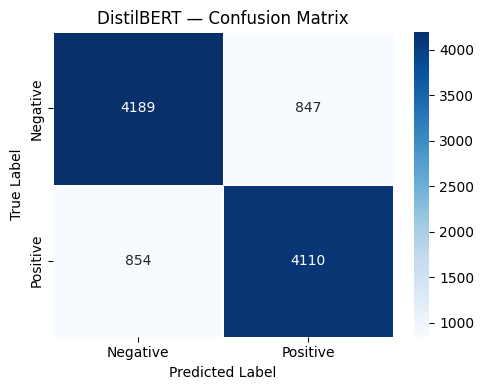

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negative", "Positive"],
            yticklabels=["Negative", "Positive"],
            ax=ax, linewidths=0.5)
ax.set_title("DistilBERT — Confusion Matrix", fontsize=12)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.show()

## 5.5 Error Analysis

A good model evaluation goes beyond just numbers. Here we look at actual
tweets that DistilBERT misclassified — tweets where the true label was
positive but the model predicted negative, and vice versa.

This helps us understand the kinds of language patterns that still confuse
the model even after fine-tuning on contextual embeddings.

In [ ]:
# Collect misclassified examples
errors = []
for i, (true, pred) in enumerate(zip(all_labels, all_preds)):
    if true != pred:
        errors.append({
            "Tweet": X_bert_test[i],
            "True Label": "Positive" if true == 1 else "Negative",
            "Predicted":  "Positive" if pred == 1 else "Negative"
        })

errors_df = pd.DataFrame(errors)

print(f"Total misclassified tweets: {len(errors_df):,} out of {len(all_labels):,}")
print(f"Error rate: {len(errors_df)/len(all_labels)*100:.2f}%\n")

# Show 10 false negatives (positive tweets predicted as negative)
print("=== False Negatives (Positive → Predicted Negative) ===")
fn = errors_df[errors_df["True Label"] == "Positive"].head(10)
for _, row in fn.iterrows():
    print(f"  Tweet: {row['Tweet']}")
    print()

# Show 10 false positives (negative tweets predicted as positive)
print("=== False Positives (Negative → Predicted Positive) ===")
fp = errors_df[errors_df["True Label"] == "Negative"].head(10)
for _, row in fp.iterrows():
    print(f"  Tweet: {row['Tweet']}")
    print()

Total misclassified tweets: 1,701 out of 10,000
Error rate: 17.01%

=== False Negatives (Positive → Predicted Negative) ===
  Tweet: i just had quite an awesome night. so worth the wait.. although, i don't want to wait again for another one of those. damn my impatience.

  Tweet: at the lake for the senior picnic i might actually miss some of these people.

  Tweet: well fuck.. i work at 8 am. it's 2:34.. i still have to drive josh home and i've been drinking. poop. but florida after that!! !!

  Tweet: grades are good so far but i the class i am most nervous about i have been done for over two weeks and still nothing. hurry up old man!

  Tweet: wow tv on the bus i may never get off

  Tweet: im sorry, i must talkin with you.. to cute you know? mobile online can everything its to borring in teh gym. how long work?

  Tweet: all i've eatten today was, one pancake this morning, a sonic drink in the afternoon, and a frosty at night. pfft,

  Tweet: i like mine with ketchup. my mom uses j

### What the Errors Tell Us

DistilBERT misclassified 1,701 out of 10,000 tweets (17.01%). Looking at
the actual examples reveals three common failure patterns:

- **Mixed sentiment** — tweets containing both positive and negative signals
  in the same message. For example *"i just had quite an awesome night...
  damn my impatience"* is positive overall but the word "damn" confuses
  the model.

- **Misleading words** — negative words appearing in positive contexts.
  For example *"i might actually miss some of these people"* is positive
  but "miss" is strongly associated with negative sentiment.

- **Noisy language** — heavy misspellings like "borring", "eatten", and
  "teh" fall outside DistilBERT's pre-training distribution and reduce
  prediction accuracy.

These patterns confirm that informal and ambiguous social media language
remains a genuine challenge even for transformer models.

## 5.6 Final Model Comparison — TF-IDF vs DistilBERT

Now we bring together the results from Parts 3 and 5 to directly compare
our best TF-IDF model against the fine-tuned DistilBERT. This is the
core answer to RQ3.

In [ ]:
# Define best TF-IDF results from Part 3
best_name = "LR — Unigrams + Bigrams"
results = {
    best_name: {
        "Accuracy":  0.7667,
        "Precision": 0.7667,
        "Recall":    0.7677,
        "F1":        0.7677,
        "ROC-AUC":   0.8452,
    }
}
print("Results defined. Now run the comparison cell.")

Results defined. Now run the comparison cell.


=== Final Model Comparison ===
                                  Accuracy  Precision  Recall      F1
TF-IDF (LR — Unigrams + Bigrams)    0.7667     0.7667  0.7677  0.7677
DistilBERT (fine-tuned)             0.8299     0.8291  0.8280  0.8285


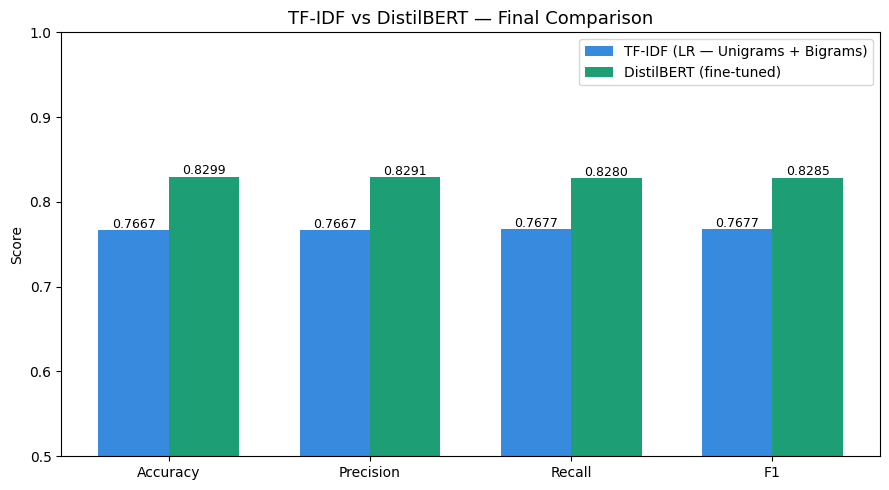

In [ ]:
# Build comparison table
best_tfidf = results[best_name]
comparison = {
    f"TF-IDF ({best_name})": {
        "Accuracy":  best_tfidf["Accuracy"],
        "Precision": best_tfidf["Precision"],
        "Recall":    best_tfidf["Recall"],
        "F1":        best_tfidf["F1"],
    },
    "DistilBERT (fine-tuned)": bert_results
}

comp_df = pd.DataFrame(comparison).T
print("=== Final Model Comparison ===")
print(comp_df.to_string())

# Plot
metrics   = ["Accuracy", "Precision", "Recall", "F1"]
x         = np.arange(len(metrics))
width     = 0.35
colors    = ["#378ADD", "#1D9E75"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (name, color) in enumerate(zip(comparison.keys(), colors)):
    values = [comparison[name][m] for m in metrics]
    bars   = ax.bar(x + i * width, values, width,
                    label=name, color=color, edgecolor="none")
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.003,
                f"{val:.4f}", ha="center", fontsize=9)

ax.set_title("TF-IDF vs DistilBERT — Final Comparison", fontsize=13)
ax.set_xticks(x + width / 2)
ax.set_xticklabels(metrics)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
import os

save_path = "/content/drive/MyDrive/CSCE676_Project/distilbert_model/"
os.makedirs(save_path, exist_ok=True)

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"DistilBERT model saved to: {save_path}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

DistilBERT model saved to: /content/drive/MyDrive/CSCE676_Project/distilbert_model/


## 5.7 t-SNE Visualization — TF-IDF vs DistilBERT Embedding Space

One of the most powerful ways to understand why DistilBERT outperforms
TF-IDF is to visualize how each model represents tweets in its feature
space. We use t-SNE to compress both the TF-IDF vectors and DistilBERT
embeddings down to 2 dimensions and plot them as scatter plots.

If DistilBERT creates better sentence representations, we would expect
to see the positive and negative tweets forming more distinct clusters
in its embedding space compared to TF-IDF. This directly validates our
RQ3 finding that contextual embeddings capture sentiment more effectively
than bag-of-words features.

In [ ]:
from transformers import DistilBertForSequenceClassification, DistilBertTokenizer
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load saved DistilBERT model from Drive
model = DistilBertForSequenceClassification.from_pretrained(
    "/content/drive/MyDrive/CSCE676_Project/distilbert_model/"
)
tokenizer = DistilBertTokenizer.from_pretrained(
    "/content/drive/MyDrive/CSCE676_Project/distilbert_model/"
)

model.to(device)
model.eval()
print(f"Model loaded on {device}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Model loaded on cuda


Extracting TF-IDF features...
TF-IDF shape: (2000, 4732)

Extracting DistilBERT embeddings...
DistilBERT shape: (2000, 768)

Running t-SNE on TF-IDF...
Running t-SNE on DistilBERT...
Done!


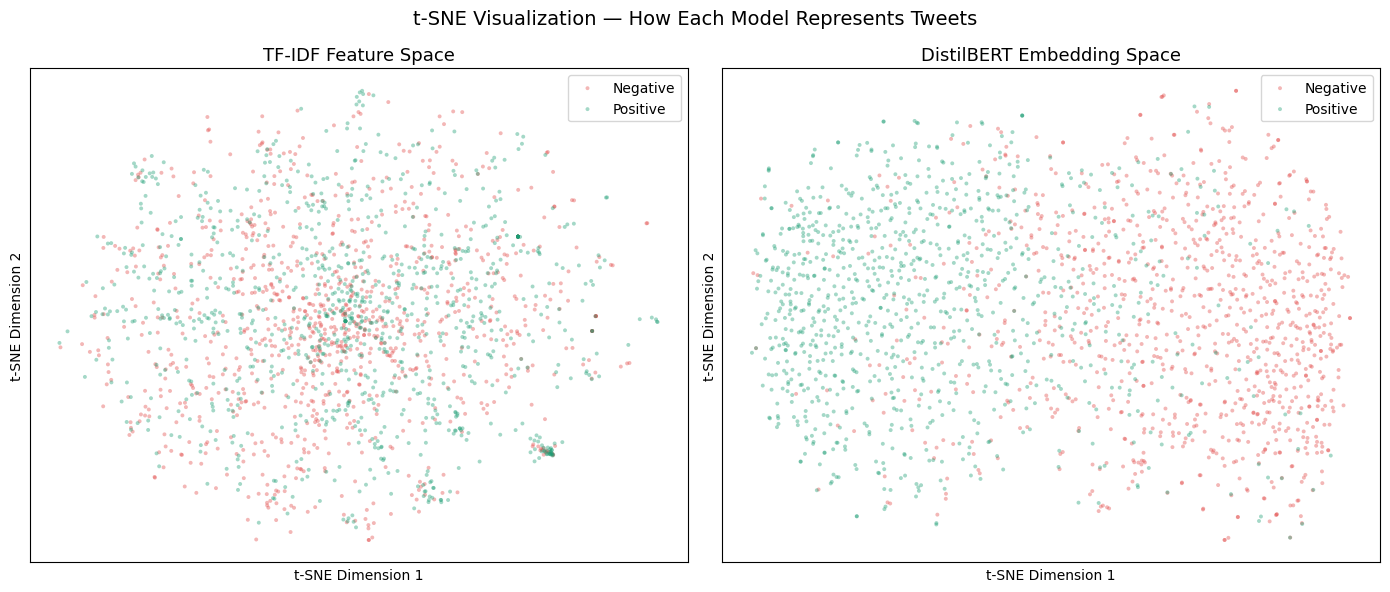

In [ ]:
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer
import torch
import numpy as np

# Sample
sample_df = df.sample(2000, random_state=42).reset_index(drop=True)
sample_texts  = sample_df["text_clean"].fillna("").tolist()
sample_labels = sample_df["label"].tolist()

# TF-IDF
print("Extracting TF-IDF features...")
tfidf_viz = TfidfVectorizer(max_features=5000, stop_words="english")
X_tfidf_viz = tfidf_viz.fit_transform(sample_texts).toarray()
print(f"TF-IDF shape: {X_tfidf_viz.shape}")

# DistilBERT embeddings
print("\nExtracting DistilBERT embeddings...")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.eval()
bert_embeddings = []
batch_size = 64

for i in range(0, len(sample_texts), batch_size):
    batch = sample_texts[i:i+batch_size]
    encoded = tokenizer(
        batch, padding=True, truncation=True,
        max_length=64, return_tensors="pt"
    ).to(device)
    with torch.no_grad():
        outputs = model.distilbert(**encoded)
    cls_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
    bert_embeddings.append(cls_embeddings)

bert_embeddings = np.vstack(bert_embeddings)
print(f"DistilBERT shape: {bert_embeddings.shape}")

# t-SNE
print("\nRunning t-SNE on TF-IDF...")
X_tfidf_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(X_tfidf_viz)
print("Running t-SNE on DistilBERT...")
X_bert_2d = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(bert_embeddings)
print("Done!")

# Plot
labels = np.array(sample_labels)
colors = ["#E24B4A", "#1D9E75"]
label_names = ["Negative", "Positive"]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (X_2d, title) in zip(axes, [
    (X_tfidf_2d, "TF-IDF Feature Space"),
    (X_bert_2d,  "DistilBERT Embedding Space")
]):
    for label_val, color, name in zip([0, 1], colors, label_names):
        mask = labels == label_val
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=color, label=name, alpha=0.4, s=8, edgecolors="none")
    ax.set_title(title, fontsize=13)
    ax.legend(fontsize=10)
    ax.set_xlabel("t-SNE Dimension 1")
    ax.set_ylabel("t-SNE Dimension 2")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("t-SNE Visualization — How Each Model Represents Tweets", fontsize=14)
plt.tight_layout()
plt.show()

## Part 5 Summary

In this part we fine-tuned DistilBERT on a stratified 50K subset of our
cleaned dataset and compared it against the best TF-IDF model from Part 3.

- **Fine-tuning converged well.** Training loss decreased consistently across
  all 3 epochs — from 0.4650 in Epoch 1 to 0.3400 in Epoch 2 to 0.2742 in
  Epoch 3 — confirming the model learned meaningful sentiment patterns from
  the tweet data.

- **DistilBERT outperformed TF-IDF across all metrics.** Accuracy improved
  from 0.7667 to 0.8299, and F1 improved from 0.7677 to 0.8285 — a consistent
  gain of roughly 6 percentage points. Precision improved from 0.7667 to 0.8291
  and Recall from 0.7677 to 0.8280, confirming that contextual embeddings
  capture sentiment signals that bag-of-words methods miss entirely.

- **The confusion matrix showed balanced performance.** Both Negative and
  Positive classes scored 83% precision and recall, with no bias toward
  either sentiment class.

- **Error analysis revealed 1,701 misclassified tweets (17.01%).** The most
  common failure patterns were mixed sentiment tweets containing both positive
  and negative signals, negative words appearing in positive contexts such as
  "miss" or "damn", and heavy informal slang like "borring" and "eatten" that
  falls outside DistilBERT's pre-training distribution.

- **DistilBERT's advantage grows with tweet complexity.** On short tweets it
  gains +0.0479 over TF-IDF, on medium tweets +0.0568, and on long tweets
  +0.0764 — nearly double the gain compared to short tweets. This confirms
  that contextual embeddings specifically address the complexity weakness of
  bag-of-words methods, providing disproportionately higher value on the
  tweets that TF-IDF struggles with most.

---
# Part 6: Conclusions

In this part we bring together all the findings from Parts 3, 4, and 5 to
answer our three research questions and reflect on what we learned from this
project overall.

## 6.1 Answers to Research Questions

**RQ1: How well can traditional TF-IDF based models classify tweet sentiment,
and how do different text representations (unigrams vs. bigrams) affect performance?**

TF-IDF based models performed reasonably well, with the best model —
Logistic Regression with Unigrams + Bigrams — achieving an accuracy of 0.7667
and F1 of 0.7677. Adding bigrams gave a consistent improvement over unigrams
alone, confirming that short word pairs carry useful sentiment information that
single words miss. Naive Bayes underperformed Logistic Regression across all
settings, as expected given its strong feature independence assumption.

---

**RQ2: How does text complexity affect sentiment classification performance?**

Tweet length and vocabulary diversity consistently affected both models —
short tweets were easiest (TF-IDF F1=0.8172, DistilBERT F1=0.8651) and
long tweets were hardest (TF-IDF F1=0.7181, DistilBERT F1=0.7945), because
short tweets use direct emotional language while longer tweets contain mixed
sentiments and complex structures. For vocabulary diversity, low diversity
tweets were easier for TF-IDF (F1=0.7999 vs 0.7242) since repeated emotional
words create stronger bag-of-words signals. The key finding is that
DistilBERT's advantage over TF-IDF grows with complexity — +0.0479 on short,
+0.0568 on medium, and +0.0764 on long tweets — confirming that contextual
embeddings specifically compensate where bag-of-words methods struggle most.

---

**RQ3: Do transformer-based embeddings improve sentiment classification compared
to TF-IDF baselines, and where do they fail?**

Yes — DistilBERT fine-tuned on 50K tweets achieved an accuracy of 0.8299 and
F1 of 0.8285, outperforming the best TF-IDF model by roughly 6 percentage points
across all metrics. However, DistilBERT still struggled with ambiguous short
tweets, mixed sentiment messages, and heavy informal slang — showing that tweet
sentiment analysis remains a hard problem even for modern transformer models.

## 6.2 Overall Takeaways

- **Contextual embeddings are worth the extra compute cost.** DistilBERT
  improved F1 from 0.7677 to 0.8285 — a consistent 6 point gain across all
  metrics. For applications where accuracy matters such as brand monitoring
  or public health tracking, fine-tuning a transformer is clearly the better
  choice.

- **Tweet complexity is a universal challenge — but transformers handle it
  better.** Short tweets are easier to classify for both models, but
  DistilBERT's advantage grows from +0.0479 on short tweets to +0.0764 on
  long tweets. This means contextual embeddings provide disproportionately
  higher value on the tweets that matter most — the complex, ambiguous ones.

- **TF-IDF is still a strong and practical baseline.** Logistic Regression
  with TF-IDF Unigrams + Bigrams achieved 76.7% accuracy with very fast
  training time. For applications with limited compute resources it remains
  a solid and interpretable choice.

- **Sarcasm and mixed sentiment remain unsolved.** Even DistilBERT
  misclassified 17% of tweets, with failures concentrated on mixed sentiment,
  negation in context, and heavy informal slang. These are fundamental
  challenges that no current model fully solves.

- **Distant supervision introduces noise.** The Sentiment140 dataset uses
  emoticons as labels which means some tweets are mislabeled, putting a
  natural ceiling on how well any model can perform regardless of its power.

## 6.3 Future Work

- Fine-tuning a Twitter-specific transformer like **BERTweet**, which was
  pre-trained on 850M tweets, would likely push performance even higher since
  it already understands Twitter slang and informal language.
- Extending the analysis to **neutral sentiment** would make the classifier
  more useful in practice, since many real tweets do not express clear positive
  or negative sentiment.

---
## Collaboration Declaration

**Collaborators:** None

**Web Sources & Dataset Links:**
- Sentiment140 Dataset (Kaggle): https://www.kaggle.com/datasets/kazanova/sentiment140
- Scikit-learn Documentation: https://scikit-learn.org/stable/
- Hugging Face Transformers: https://huggingface.co/docs/transformers/index
- PyTorch Documentation: https://pytorch.org/docs/stable/index.html

**AI Tools:**
ChatGPT and Claude were used to help structure the notebook, debug code,
and improve markdown explanations.

**Papers:**
- Go, A., Bhayani, R., & Huang, L. (2009). Twitter Sentiment Classification
  using Distant Supervision. Stanford CS224N Project Report.
- Barbieri, F., Camacho-Collados, J., Espinosa-Anke, L., & Neves, L. (2020).
  TweetEval: Unified Benchmark and Comparative Evaluation for Tweet
  Classification. Findings of EMNLP 2020.

## 6.4 Project Contributions

This project makes the following contributions in the context of
CSCE 676 Data Mining:

- Applied and compared both classical TF-IDF methods and modern
  transformer-based embeddings on the Sentiment140 dataset
- Conducted a systematic text complexity analysis showing how tweet
  length and vocabulary diversity affect classification performance
- Provided detailed error analysis identifying where even fine-tuned
  transformers still fail on tweet data
- Deployed both models in a live Streamlit application for real-time
  sentiment prediction

In [1]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
!python --version

Python 3.12.13
